In [22]:
%load_ext autoreload
%autoreload 2
%env TORCH_COMPILE_DISABLE=1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: TORCH_COMPILE_DISABLE=1


In [23]:
from brain_image.model.encoder.eeg_encoder.atms import AtmsEEGEncoder, FullAttention
from brain_image.model.encoder.eeg_encoder.union import create_eeg_encoder
from brain_image.data.datamodule import EEGDataModule
from brain_image.data.dataset.things_eeg2_dataset import ThingsEEG2DatasetConfig
from brain_image.data.data import get_from_batch

from pathlib import Path
import yaml
import numpy as np
import matplotlib.pyplot as plt
from torch import Tensor
import torch

In [24]:
device = torch.device("cuda")

In [25]:
# Build sub -> checkpoint path mapping from experiments/subs
SUBS_DIR = Path("experiments/subs")
ENCODER_CONFIG = {
    "eeg_encoder": "atms",
    "d_channels": 63,
    "d_time": 250,
    "d_output": 768,
    "d_eeg": 40,
    "dropout": 0.5,
    "patch_out_size": 36,
    "hidden_dim": 1024,
    "flatten": True,
}

sub_to_cp: dict[int, Path] = {}
for exp_dir in sorted(SUBS_DIR.iterdir()):
    hparams_path = exp_dir / "version_0" / "hparams.yaml"
    if not hparams_path.exists():
        continue
    hparams = yaml.safe_load(hparams_path.read_text())
    subs = hparams.get("dataset_config", {}).get("subs") or hparams.get("config", {}).get("subs")
    if not subs:
        continue
    sub = subs[0]
    cp = exp_dir / "version_0" / "checkpoints" / "last.ckpt"
    if cp.exists():
        sub_to_cp[sub] = cp

for sub, cp in sorted(sub_to_cp.items()):
    print(f"sub-{sub:02d} -> {cp}")

sub-01 -> experiments/subs/251025024826gpfciv-slurmarr14442553_0/version_0/checkpoints/last.ckpt
sub-02 -> experiments/subs/251025024829noumqd-slurmarr14442553_1/version_0/checkpoints/last.ckpt
sub-03 -> experiments/subs/251025024837fctayb-slurmarr14442553_2/version_0/checkpoints/last.ckpt
sub-04 -> experiments/subs/251025024835zbdugy-slurmarr14442553_3/version_0/checkpoints/last.ckpt
sub-05 -> experiments/subs/251025024840bjgucn-slurmarr14442553_4/version_0/checkpoints/last.ckpt
sub-06 -> experiments/subs/251025024849accamw-slurmarr14442553_5/version_0/checkpoints/last.ckpt
sub-07 -> experiments/subs/251025024848tpjvws-slurmarr14442553_6/version_0/checkpoints/last.ckpt
sub-08 -> experiments/subs/251025024903wrjuxu-slurmarr14442553_7/version_0/checkpoints/last.ckpt
sub-10 -> experiments/subs/251025024918lgakcy-slurmarr14442553_9/version_0/checkpoints/last.ckpt


In [28]:
def enable_output_attention(encoder: AtmsEEGEncoder):
    for module in encoder.modules():
        if isinstance(module, FullAttention):
            module.output_attention = True


def extract_attention_maps(encoder: AtmsEEGEncoder, eeg: Tensor, sub=None) -> list[Tensor]:
    """
    Extract per-layer attention maps [B, H, C, C] from the iTransformer encoder.
    Calls the inner Encoder directly to capture attns, which iTransformer.forward discards.
    """
    itrans = encoder.encoder
    with torch.no_grad():
        enc_out = itrans.enc_embedding(eeg, None, sub)
        _, attns = itrans.encoder(enc_out, attn_mask=None)
    return attns  # list[Tensor[B, H, C, C]], one per layer

In [29]:
from brain_image.utils import get_submodules_with_pattern

def load_encoder_for_attention(config: dict, cp: Path, device) -> AtmsEEGEncoder:
    """
    Load an AtmsEEGEncoder from a checkpoint, only restoring the iTransformer
    (encoder.*) weights. The post-attention layers (patch_embedding / proj /
    enc_eeg / proj_eeg) differ between checkpoint versions and are not needed
    for attention map extraction.
    """
    encoder = create_eeg_encoder(config)
    ckpt = torch.load(cp, map_location="cpu")
    # Only keep iTransformer weights — these match across all versions
    itrans_sd = get_submodules_with_pattern(
        ckpt["state_dict"], r"eeg_encoder\.encoder\.", get_full_name=False
    )
    missing, unexpected = encoder.encoder.load_state_dict(itrans_sd, strict=False)
    if missing:
        print(f"  [warn] missing: {missing[:3]}{'...' if len(missing) > 3 else ''}")
    if unexpected:
        print(f"  [warn] unexpected: {unexpected[:3]}{'...' if len(unexpected) > 3 else ''}")
    return encoder.eval().to(device)


# For each sub: load encoder + EEG test data, extract attention, compute mean-received
layer_idx = 0

sub_received: dict[int, np.ndarray] = {}
sub_received_std: dict[int, np.ndarray] = {}

for sub, cp in sorted(sub_to_cp.items()):
    print(f"Processing sub-{sub:02d}...")

    encoder = load_encoder_for_attention(ENCODER_CONFIG, cp, device)
    enable_output_attention(encoder)

    data_config = ThingsEEG2DatasetConfig(subs=[sub])
    data_module = EEGDataModule(data_config)
    batch = next(iter(data_module.create_dataloader("test")))

    eeg = get_from_batch("eeg_data", batch, Tensor).to(device)
    attns = extract_attention_maps(encoder, eeg)

    attn = attns[layer_idx].detach().cpu().float()  # [B, H, C, C]
    B, H, C, _ = attn.shape
    attn_flat = attn.view(-1, C, C)       # [B*H, C, C]
    received_per = attn_flat.mean(dim=1)  # [B*H, C]

    sub_received[sub] = received_per.mean(0).numpy()
    sub_received_std[sub] = received_per.std(0).numpy()

print(f"\nDone. C={C}, H={H}, B={B}")

Processing sub-01...
Processing sub-02...
Processing sub-03...
Processing sub-04...
Processing sub-05...
Processing sub-06...
Processing sub-07...
Processing sub-08...
Processing sub-10...

Done. C=63, H=4, B=128


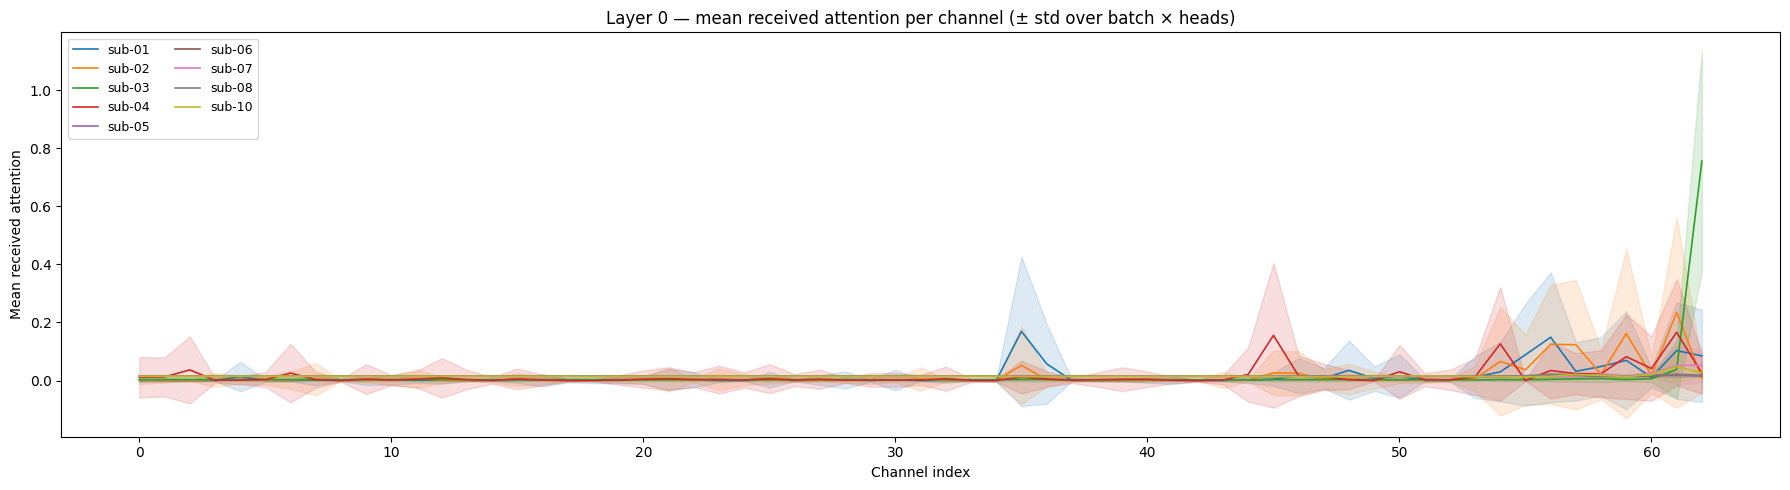

In [30]:
# Plot mean-received attention per channel for each subject
fig, ax = plt.subplots(figsize=(18, 5))

xs = np.arange(C)
cmap = plt.get_cmap("tab10")

for i, (sub, received) in enumerate(sorted(sub_received.items())):
    color = cmap(i % 10)
    std = sub_received_std[sub]
    ax.plot(xs, received, label=f"sub-{sub:02d}", color=color, linewidth=1.2)
    ax.fill_between(xs, received - std, received + std, alpha=0.15, color=color)

ax.set_xlabel("Channel index")
ax.set_ylabel("Mean received attention")
ax.set_title(f"Layer {layer_idx} — mean received attention per channel (± std over batch × heads)")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

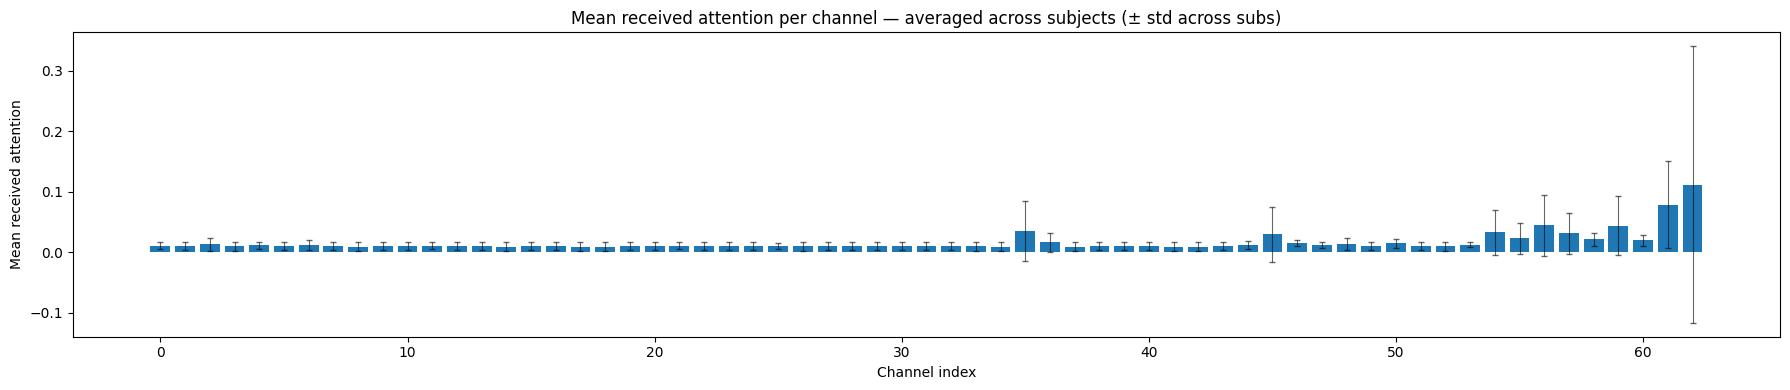

Top-5 most attended channels (avg): [62 61 56 59 35]
Top-5 least attended channels (avg): [42 34 14  8 41]


In [31]:
# Rank channels by mean received attention, averaged across subjects
all_received = np.stack(list(sub_received.values()))  # [n_subs, C]
mean_across_subs = all_received.mean(axis=0)
std_across_subs  = all_received.std(axis=0)

fig, ax = plt.subplots(figsize=(18, 4))
kw = dict(capsize=2, error_kw={"ecolor": "black", "alpha": 0.6, "elinewidth": 0.8})
ax.bar(xs, mean_across_subs, yerr=std_across_subs, **kw)
ax.set_xlabel("Channel index")
ax.set_ylabel("Mean received attention")
ax.set_title("Mean received attention per channel — averaged across subjects (± std across subs)")
plt.tight_layout()
plt.show()

top5 = np.argsort(mean_across_subs)[::-1][:5]
bot5 = np.argsort(mean_across_subs)[:5]
print(f"Top-5 most attended channels (avg): {top5}")
print(f"Top-5 least attended channels (avg): {bot5}")